In [2]:
### Function Seven

In [3]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

In [4]:
X = np.load("function_7/initial_inputs.npy")
X = np.append(X, [[0.029000, 0.491900, 0.247000, 0.218000, 0.420800, 0.731000],
                 [0.000050, 0.411098, 0.228833, 0.144114, 0.346375, 0.736693],
                 [0.000001, 0.193675, 0.623099, 0.079174, 0.348890, 0.858315],
                  [0.009000, 0.506755, 0.009000, 0.009000, 0.346587, 0.841719],
                  	[0.000001, 0.237979, 0.404631, 0.121878, 0.334399, 0.759561],
                  [0.076968, 0.579575, 0.866761, 0.221407, 0.017187, 0.862321],
                  [0.081330, 0.682424, 0.427299, 0.178955, 0.628009, 0.327001],
                  [0.397481, 0.481957, 0.995121, 0.070858, 0.210922, 0.894747],
                  [0.000099, 0.999999, 0.999999, 0.000099, 0.000099, 0.000099],
                  [0.000099, 0.000099, 0.999900, 0.000099, 0.000099, 0.573262],
                  [0.000001, 0.000001, 0.451211, 0.000001, 0.150686, 0.999999],
                  [0.000010, 0.324538, 0.316732, 0.132996, 0.340387, 0.748127]
                 ],
              axis=0)

In [5]:
y= np.load("function_7/initial_outputs.npy")
y = np.append(y, [1.3159104245362119,
                 1.5250340981229598,
                 1.484140720411121,
                 0.4635446910534653,
                 1.9993628649406798,
                 0.8214784402068228,
                 0.24858502604330204,
                 0.8852200593800396,
                 0.006742683345401777,
                 0.11554102170838587,
                 0.36905511970312405,
                 1.804396780440382,
                 1.9445079828358085],
              axis=0)

In [6]:
max(y)

1.9993628649406798

In [6]:
X


array([[2.72623822e-01, 3.24495362e-01, 8.97108810e-01, 8.32951152e-01,
        1.54062685e-01, 7.95863623e-01],
       [5.43002577e-01, 9.24693904e-01, 3.41567459e-01, 6.46485849e-01,
        7.18440327e-01, 3.43132664e-01],
       [9.08322480e-02, 6.61529382e-01, 6.59309106e-02, 2.58577008e-01,
        9.63452851e-01, 6.40265398e-01],
       [1.18866975e-01, 6.15054940e-01, 9.05816385e-01, 8.55300304e-01,
        4.13631429e-01, 5.85235628e-01],
       [6.30217641e-01, 8.38096896e-01, 6.80013052e-01, 7.31895090e-01,
        5.26736715e-01, 3.48429213e-01],
       [7.64919173e-01, 2.55882917e-01, 6.09084224e-01, 2.18079042e-01,
        3.22942769e-01, 9.57936551e-02],
       [5.78955420e-02, 4.91672219e-01, 2.47422224e-01, 2.18118436e-01,
        4.20428330e-01, 7.30969843e-01],
       [1.95251881e-01, 7.92266506e-02, 5.54580462e-01, 1.70566820e-01,
        1.49441764e-02, 1.07031710e-01],
       [6.42302982e-01, 8.36874547e-01, 2.17926915e-02, 1.01488010e-01,
        6.83070828e-01, 

In [7]:
y

array([0.6044327 , 0.56275307, 0.00750324, 0.0614243 , 0.2730468 ,
       0.08374657, 1.3649683 , 0.09264495, 0.0178696 , 0.03356494,
       0.0735163 , 0.2063097 , 0.00882563, 0.26840032, 0.61152553,
       0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
       0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
       0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
       1.31591042, 1.5250341 , 1.48414072, 0.46354469, 1.99936286,
       0.82147844, 0.24858503, 0.88522006, 0.00674268, 0.11554102])

In [8]:
# 2. Fit GP (Using Matern + WhiteKernel to handle noise in model training)
kernel = C(1.0) * Matern(length_scale=[0.5]*6,length_scale_bounds=(0.01, 10.0), nu=2.5) + WhiteKernel(noise_level=1)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
gp.fit(X, y)

/Users/theshiekh/Library/Caches/pypoetry/virtualenvs/emeritus-poXcNCb8-py3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * Matern...noise_level=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

In [9]:
print("Length Scales:", gp.kernel_.get_params()['k1__k2__length_scale'])

Length Scales: [ 0.9786685  10.          0.37636232  0.5374032   0.24075096  0.49376017]


In [10]:
def expected_improvement(x_test, gp, y_max, xi=0.1):
    x_test = np.atleast_2d(x_test)
    mu, sigma = gp.predict(x_test, return_std=True)
    
    # Avoid division by zero
    sigma = np.maximum(sigma, 1e-9)
    
    imp = mu - y_max - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    return -ei.flatten() # Return negative for minimization

In [11]:
from scipy.stats import qmc

# 1. Setup Sobol Sampler for 6D
# We use a power of 2 (32) for Sobol efficiency
d = 6
n_starts = 32
sampler = qmc.Sobol(d=d, scramble=True)
initial_guesses = sampler.random(n=n_starts)


# 3. Iterate through multiple starts to find the global EI maximum
best_ei_found = np.inf
best_next_point = None
current_best_y = np.max(y)

for x0 in initial_guesses:
    res = minimize(
        expected_improvement, 
        x0, 
        args=(gp, current_best_y), 
        bounds=[(0, 1)] * d, 
        method='L-BFGS-B'
    )
    
    if res.fun < best_ei_found:
        best_ei_found = res.fun
        best_next_point = res.x

print(f"Next point to sample: {best_next_point}")

Next point to sample: [0.65381764 0.15836188 0.31149066 0.3315378  0.25509731 0.96966009]


In [12]:
# Third iteration, continuing to exploit with moderate exploration

In [13]:
def ucb_loss(x_test, kappa=10):
    """
    UCB Acquisition Function
    kappa=2.576 corresponds to a 99% confidence interval.
    Common values: 1.0 (exploitative) to 5.0+ (exploratory).
    """
    mu, sigma = gp.predict(x_test.reshape(1, -1), return_std=True)
    
    # UCB Formula
    ucb = mu + kappa * sigma
    
    # Return NEGATIVE because 'minimize' will find the highest score
    return -ucb

In [15]:
x_init = X[np.argmax(y)] # Start from current best
res = minimize(ucb_loss, x_init, bounds=[(0, 1)]*6, method='L-BFGS-B')

print(f"Current Best Y: {np.max(y)}")
print(f"Next Suggested Point: {res.x}")

Current Best Y: 1.9993628649406798
Next Suggested Point: [0.         0.         0.45121159 0.         0.150686   1.        ]


In [16]:
next_point = best_next_point

In [17]:
import numpy as np


# 1. Get the indices that would sort the array from lowest to highest
sorted_indices = np.argsort(y)

# 2. Use those indices to get the sorted values
sorted_values = y[sorted_indices]

# 3. Display the Rank, Original Index, and Value
print(f"{'Rank':<6} | {'Orig Index':<10} | {'Value':<10}")
print("-" * 32)
for rank, idx in enumerate(sorted_indices):
    print(f"{rank:<6} | {idx:<10} | {sorted_values[rank]:.2f}")

Rank   | Orig Index | Value     
--------------------------------
0      | 19         | 0.00
1      | 27         | 0.00
2      | 26         | 0.00
3      | 38         | 0.01
4      | 21         | 0.01
5      | 2          | 0.01
6      | 12         | 0.01
7      | 15         | 0.01
8      | 8          | 0.02
9      | 20         | 0.02
10     | 28         | 0.02
11     | 9          | 0.03
12     | 18         | 0.04
13     | 3          | 0.06
14     | 17         | 0.07
15     | 10         | 0.07
16     | 5          | 0.08
17     | 7          | 0.09
18     | 29         | 0.10
19     | 22         | 0.10
20     | 39         | 0.12
21     | 11         | 0.21
22     | 36         | 0.25
23     | 13         | 0.27
24     | 4          | 0.27
25     | 16         | 0.27
26     | 33         | 0.46
27     | 23         | 0.48
28     | 25         | 0.52
29     | 1          | 0.56
30     | 0          | 0.60
31     | 14         | 0.61
32     | 24         | 0.68
33     | 35         | 0.82
34     | 37     

In [18]:
import torch
# Custom Labels: Start with all zeros (Negative)
y_labels = np.zeros(len(X))


positive_indices = [31,32,6,30,24]
y_labels[positive_indices] = 1

# 1. Setup Data
X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True)

y_tensor = torch.tensor(y_labels, dtype=torch.float32).reshape(-1, 1)

In [19]:

import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define a deeper architecture
model = nn.Sequential(
    nn.Linear(6, 36),      # Hidden layer: 2 inputs -> 10 neurons
    nn.ReLU(),             # Non-linear activation
    nn.Linear(36, 1),      # Output layer: 10 neurons -> 1 output
    nn.Sigmoid()
)

# 2. Setup the rest as before
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam is better for deeper nets
criterion = nn.BCELoss()

# 3. Training Loop
for _ in range(2000):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
       
# Importance scores
deep_importance = X_tensor.grad.abs().sum(dim=1).detach().numpy()

print("Point | Deep Importance Score")
for i, score in enumerate(deep_importance):
    print(f"{i:2d}    | {score:.4f}")


Point | Deep Importance Score
 0    | 2.3961
 1    | 0.5773
 2    | 4.1902
 3    | 0.6577
 4    | 0.3655
 5    | 1.2165
 6    | 29.0574
 7    | 2.6611
 8    | 6.9781
 9    | 1.6972
10    | 5.7092
11    | 14.0674
12    | 5.7771
13    | 22.2808
14    | 4.6581
15    | 2.1651
16    | 5.7617
17    | 0.2986
18    | 2.5255
19    | 0.5484
20    | 2.4079
21    | 6.2074
22    | 7.1423
23    | 12.7093
24    | 60.3822
25    | 0.8412
26    | 0.9136
27    | 0.8034
28    | 3.7141
29    | 0.6398
30    | 15.3412
31    | 419.2167
32    | 344.0090
33    | 72.9146
34    | 742.2723
35    | 2.3622
36    | 3.7709
37    | 7.7434
38    | 0.5820
39    | 3.3642


In [20]:
import torch

# 1. Prepare your sample input (must be a 2D tensor)
sample_input = torch.tensor([next_point], dtype=torch.float32)

# 2. Put the model in evaluation mode
model.eval()

# 3. Use 'no_grad' to save memory and compute power
with torch.no_grad():
    prediction_prob = model(sample_input)

# 4. View results
print(f"Next point    {next_point}")
print(f"Probability of being Positive (Class 1): {prediction_prob.item():.4f}")

# Convert probability to a hard label
predicted_label = 1 if prediction_prob.item() >= 0.5 else 0
print(f"Predicted Class: {predicted_label}")


Next point    [0.65381764 0.15836188 0.31149066 0.3315378  0.25509731 0.96966009]
Probability of being Positive (Class 1): 0.0000
Predicted Class: 0


/var/folders/b1/jr7k43v1395g6gvnq7gz_qq80000gn/T/ipykernel_3235/3007046121.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  sample_input = torch.tensor([next_point], dtype=torch.float32)


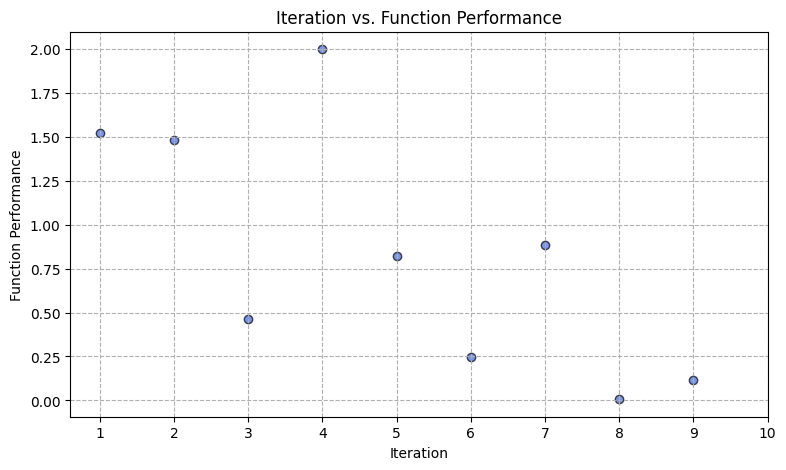

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(
    list(range(1,10)), y[-9:], color="royalblue", alpha=0.7, edgecolors="k"
)

# 2. Force the x-axis to explicitly show every number from 1 to 9
plt.xticks(list(range(1,11)))

# 3. Customization
plt.title("Iteration vs. Function Performance")
plt.xlabel("Iteration")
plt.ylabel("Function Performance")
plt.grid(True, linestyle="--", alpha=1)
plt.savefig("function_7_chart_9th_iteration.png")
plt.show()